In [1]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import json
import numpy as np
# import sys; sys.path.append("../src/")


In [2]:
dataset_name = "tweeteval_offensive"
model_name = "roberta"

In [3]:
use_cache = True # Set to false if you wanna do it from scratch
cache_dir = Path("../scripts/_cache")

In [4]:
prefix = ""

## Soft stability rates for different explanations

In [5]:
lime_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_lime_soft_stability_rates.json"
shap_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_shap_soft_stability_rates.json"
intgrad_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_intgrad_soft_stability_rates.json"
mfaba_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_mfaba_soft_stability_rates.json"
random_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_random_soft_stability_rates.json"

In [6]:
if lime_stability_rates_file.exists() and use_cache:
    print("Loading LIME soft stability rates")
    with open(lime_stability_rates_file, 'r') as f:
        lime_stability_rates_dict = json.load(f)
        lime_stability_rates = lime_stability_rates_dict['soft_stability_rates']

Loading LIME soft stability rates


In [7]:
if shap_stability_rates_file.exists() and use_cache:
    print("Loading SHAP soft stability rates")
    with open(shap_stability_rates_file, 'r') as f:
        shap_stability_rates_dict = json.load(f)
        shap_stability_rates = shap_stability_rates_dict['soft_stability_rates']

Loading SHAP soft stability rates


In [8]:
if intgrad_stability_rates_file.exists() and use_cache:
    print("Loading IntGrad soft stability rates")
    with open(intgrad_stability_rates_file, 'r') as f:
        intgrad_stability_rates_dict = json.load(f)
        intgrad_stability_rates = intgrad_stability_rates_dict['soft_stability_rates']

Loading IntGrad soft stability rates


In [9]:
if mfaba_stability_rates_file.exists() and use_cache:
    print("Loading MFABA soft stability rates")
    with open(mfaba_stability_rates_file, 'r') as f:
        mfaba_stability_rates_dict = json.load(f)
        mfaba_stability_rates = mfaba_stability_rates_dict['soft_stability_rates']

Loading MFABA soft stability rates


In [10]:
if random_stability_rates_file.exists() and use_cache:
    print("Loading Random soft stability rates")
    with open(random_stability_rates_file, 'r') as f:
        random_stability_rates_dict = json.load(f)
        random_stability_rates = random_stability_rates_dict['soft_stability_rates']

Loading Random soft stability rates


In [11]:
# Find the maximum length
lime_stability_rates = [torch.tensor(t) for t in lime_stability_rates]
max_len = max(t.size(0) for t in lime_stability_rates)
# Pad tensors to the same length with NaN
lime_stability_rates = [torch.nn.functional.pad(t, (0, max_len - t.size(0)), value=float('nan')) for t in lime_stability_rates]
lime_stability_rates = torch.stack(lime_stability_rates).cpu()

# Find the maximum length
shap_stability_rates = [torch.tensor(t) for t in shap_stability_rates]
max_len = max(t.size(0) for t in shap_stability_rates)
# Pad tensors to the same length with NaN
shap_stability_rates = [torch.nn.functional.pad(t, (0, max_len - t.size(0)), value=float('nan')) for t in shap_stability_rates]
shap_stability_rates = torch.stack(shap_stability_rates).cpu()

# Find the maximum length
intgrad_stability_rates = [torch.tensor(t) for t in intgrad_stability_rates]
max_len = max(t.size(0) for t in intgrad_stability_rates)
# Pad tensors to the same length with NaN
intgrad_stability_rates = [torch.nn.functional.pad(t, (0, max_len - t.size(0)), value=float('nan')) for t in intgrad_stability_rates]
intgrad_stability_rates = torch.stack(intgrad_stability_rates).cpu()

# Find the maximum length
mfaba_stability_rates = [torch.tensor(t) for t in mfaba_stability_rates]
max_len = max(t.size(0) for t in mfaba_stability_rates)
# Pad tensors to the same length with NaN
mfaba_stability_rates = [torch.nn.functional.pad(t, (0, max_len - t.size(0)), value=float('nan')) for t in mfaba_stability_rates]
mfaba_stability_rates = torch.stack(mfaba_stability_rates).cpu()


# Find the maximum length
random_stability_rates = [torch.tensor(t) for t in random_stability_rates]
max_len = max(t.size(0) for t in random_stability_rates)
# Pad tensors to the same length with NaN
random_stability_rates = [torch.nn.functional.pad(t, (0, max_len - t.size(0)), value=float('nan')) for t in random_stability_rates]
random_stability_rates = torch.stack(random_stability_rates).cpu()

<Figure size 640x480 with 0 Axes>

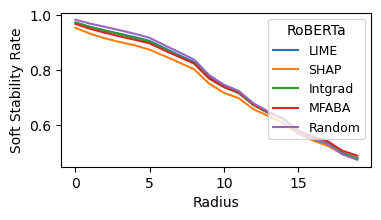

In [13]:
all_radius = list(range(0, max_len))
plt.clf()
plt.figure(figsize=(4, 2))
plt.rcParams["font.family"] = "DejaVu Sans"


plt.plot(all_radius, torch.mean(torch.nan_to_num(lime_stability_rates, nan=0), dim=0), label="LIME")
plt.plot(all_radius, torch.mean(torch.nan_to_num(shap_stability_rates, nan=0), dim=0), label="SHAP")
plt.plot(all_radius, torch.mean(torch.nan_to_num(intgrad_stability_rates, nan=0), dim=0), label="Intgrad")
plt.plot(all_radius, torch.mean(torch.nan_to_num(mfaba_stability_rates, nan=0), dim=0), label="MFABA")
plt.plot(all_radius, torch.mean(torch.nan_to_num(random_stability_rates, nan=0), dim=0), label="Random")

plt.xlabel('Radius')
plt.ylabel('Soft Stability Rate')
plt.legend(title="RoBERTa", loc="upper right", prop={'size': 9})
plt.savefig(f'_dump/{model_name}_{dataset_name}_soft.pdf', bbox_inches="tight")
plt.show()


In [14]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def make_plot_with_quantiles(radii, data, label, title, color, fs=10):
    fig, ax = plt.subplots(figsize=(4,2))
    data = np.array(data)
    qlo, qhi = np.quantile(data, [0.25, 0.75], axis=0)
    ax.plot(radii, np.median(data, axis=0), label=label, color=color)
    ax.fill_between(radii, qlo, qhi, alpha=0.2, color=color)
    
    ax.set_ylabel("Stability Rate", fontsize=fs)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.tick_params(axis="x", labelsize=fs)
    ax.tick_params(axis="y", labelsize=fs)
    ax.set_xticks([r for i, r in enumerate(radii) if i % 2 == 1])
    ax.legend(title=title, title_fontsize=fs, fontsize=fs)
    return fig

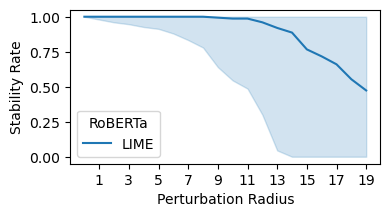

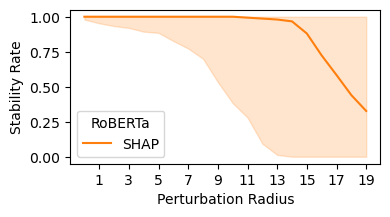

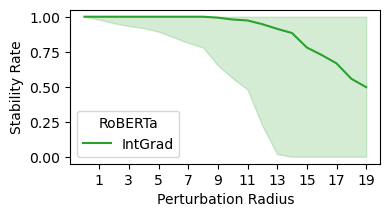

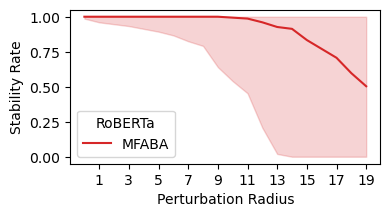

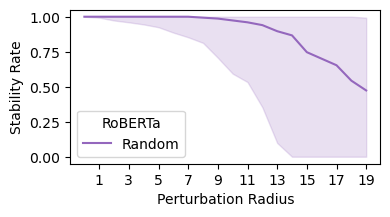

In [15]:
make_plot_with_quantiles(all_radius, torch.nan_to_num(lime_stability_rates, nan=0), "LIME", "RoBERTa", color=colors[0]);
plt.savefig(f'_dump/{model_name}_{dataset_name}_soft_lime_error_bars.pdf', bbox_inches="tight")

make_plot_with_quantiles(all_radius, torch.nan_to_num(shap_stability_rates, nan=0), "SHAP", "RoBERTa", color=colors[1]);
plt.savefig(f'_dump/{model_name}_{dataset_name}_soft_shap_error_bars.pdf', bbox_inches="tight")

make_plot_with_quantiles(all_radius, torch.nan_to_num(intgrad_stability_rates, nan=0), "IntGrad", "RoBERTa", color=colors[2]);
plt.savefig(f'_dump/{model_name}_{dataset_name}_soft_intgrad_error_bars.pdf', bbox_inches="tight")

make_plot_with_quantiles(all_radius, torch.nan_to_num(mfaba_stability_rates, nan=0), "MFABA", "RoBERTa", color=colors[3]);
plt.savefig(f'_dump/{model_name}_{dataset_name}_soft_mfaba_error_bars.pdf', bbox_inches="tight")
            
make_plot_with_quantiles(all_radius, torch.nan_to_num(random_stability_rates, nan=0), "Random", "RoBERTa", color=colors[4]);
plt.savefig(f'_dump/{model_name}_{dataset_name}_soft_random_error_bars.pdf', bbox_inches="tight")


## As a comparison, here are the certified radii when old-MuS uses lambda=0.25

In [16]:
lime_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_lime_hard_stability_radii.json"
shap_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_shap_hard_stability_radii.json"
intgrad_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_intgrad_hard_stability_radii.json"
mfaba_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_mfaba_hard_stability_radii.json"
random_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_random_hard_stability_radii.json"

In [17]:
with open(lime_hard_stability_radii_file, 'r') as f:
    cert_rs_lime_dict = json.load(f)
    cert_rs_lime = torch.tensor(cert_rs_lime_dict['lambda_to_radii']['0.250'])
    
with open(shap_hard_stability_radii_file, 'r') as f:
    cert_rs_shap_dict = json.load(f)
    cert_rs_shap = torch.tensor(cert_rs_shap_dict['lambda_to_radii']['0.250'])

with open(intgrad_hard_stability_radii_file, 'r') as f:
    cert_rs_intgrad_dict = json.load(f)
    cert_rs_intgrad = torch.tensor(cert_rs_intgrad_dict['lambda_to_radii']['0.250'])
    
with open(mfaba_hard_stability_radii_file, 'r') as f:
    cert_rs_mfaba_dict = json.load(f)
    cert_rs_mfaba = torch.tensor(cert_rs_mfaba_dict['lambda_to_radii']['0.250'])
    
with open(random_hard_stability_radii_file, 'r') as f:
    cert_rs_random_dict = json.load(f)
    cert_rs_random = torch.tensor(cert_rs_random_dict['lambda_to_radii']['0.250'])
    

In [18]:
r_max = 2.0
num_samples = cert_rs_lime.size(0)
r_ticks = torch.arange(start=0.0, end=2.0, step=0.001)

cert_stability_rates_lime = torch.tensor([(cert_rs_lime >= rt).sum() / num_samples for rt in r_ticks])
cert_stability_rates_shap = torch.tensor([(cert_rs_shap >= rt).sum() / num_samples for rt in r_ticks])
cert_stability_rates_intgrad = torch.tensor([(cert_rs_intgrad >= rt).sum() / num_samples for rt in r_ticks])
cert_stability_rates_mfaba = torch.tensor([(cert_rs_mfaba >= rt).sum() / num_samples for rt in r_ticks])
cert_stability_rates_random = torch.tensor([(cert_rs_random >= rt).sum() / num_samples for rt in r_ticks])

<Figure size 640x480 with 0 Axes>

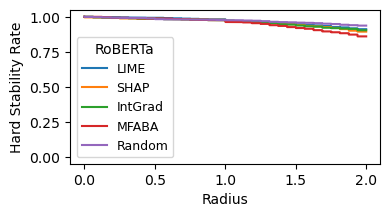

In [20]:
plt.clf()
plt.rcParams["font.family"] = "DejaVu Sans"

plt.figure(figsize=(4, 2))
plt.plot(r_ticks.numpy(), cert_stability_rates_lime, label="LIME")
plt.plot(r_ticks.numpy(), cert_stability_rates_shap, label="SHAP")
plt.plot(r_ticks.numpy(), cert_stability_rates_intgrad, label="IntGrad")
plt.plot(r_ticks.numpy(), cert_stability_rates_mfaba, label="MFABA")
plt.plot(r_ticks.numpy(), cert_stability_rates_random, label="Random")


plt.ylim([-0.05,1.05])
plt.xlabel('Radius')
plt.ylabel('Hard Stability Rate')
plt.legend(title="RoBERTa", loc="lower left", prop={'size': 9})
plt.savefig(f'_dump/{model_name}_{dataset_name}_hard.pdf', bbox_inches="tight")
plt.show()


## Combine soft and hard stability in the same plot

In [ ]:
# plt.clf()
# plt.figure(figsize=(6, 4))
# plt.plot(all_radius, lime_stability_rates.cpu().mean(dim=0).numpy(), label="LIME Soft")
# plt.plot(all_radius, shap_stability_rates.cpu().mean(dim=0).numpy(), label="SHAP Soft")
# plt.plot(all_radius, intgrad_stability_rates.cpu().mean(dim=0).numpy(), label="IntGrad Soft")
# plt.plot(all_radius, mfaba_stability_rates.cpu().mean(dim=0).numpy(), label="MFABA Soft")

# plt.plot(cert_lime_stability_rates.sort(descending=True).values, [0.001 * i for i in range(0, len(images))], label="LIME Hard", color="#1f77b4")
# plt.plot(cert_shap_stability_rates.sort(descending=True).values, [0.001 * i for i in range(0, len(images))], label="SHAP Hard", color="#ff7f0e")
# plt.plot(cert_intgrad_stability_rates.sort(descending=True).values, [0.001 * i for i in range(0, len(images))], label="IntGrad Hard", color="#2ca02c")
# plt.plot(cert_mfaba_stability_rates.sort(descending=True).values, [0.001 * i for i in range(0, len(images))], label="MFABA Hard", color="#d62728")
# plt.xlabel('Radius')
# plt.ylabel('Stability Rate')
# plt.legend(title="ViT", loc="upper right", prop={'size': 7})
# plt.title('Soft vs. Hard Stability')
# plt.savefig('_dump/vit_imagenet_softvhard_1k', bbox_inches="tight")
